# Segmentação de Clientes com K-Means sobre RFM

## 1. Objetivo

Este notebook responde uma pergunta **diferente** da segmentação por regras: em vez de
classificar clientes em faixas que nós definimos, ele pergunta **quais agrupamentos
existem naturalmente nos dados**.

| | Segmentação por regras (quantis) | Clustering (K-Means) |
|---|---|---|
| Quem define os grupos | O analista, antes de olhar | O algoritmo, a partir da geometria dos dados |
| Número de grupos | Escolhido (5 notas → regras) | Estimado (cotovelo, silhueta) |
| Auditabilidade | Alta — a regra é legível | Baixa — o grupo é um centroide |
| Sensível a outliers | Não (quantis são posicionais) | **Sim** — a distância euclidiana é dominada por extremos |
| Sensível a escala | Não | **Sim** — exige padronização |
| Quando usar | Quando as faixas de negócio já são conhecidas | Quando se quer descobrir padrões não antecipados |

As duas abordagens não competem: a comparação entre elas (seção 7) costuma ser mais
informativa que qualquer uma isolada. Se o clustering reproduzir aproximadamente as
regras, isso valida as regras. Se discordar, a discordância aponta um padrão que as
regras não capturam.

**Consequência prática do quadro acima:** aqui, ao contrário da análise por quantis, o
pré-processamento **não é opcional**. Outliers, assimetria e escala precisam ser tratados
antes de o algoritmo rodar, e a seção 3 trata os três.

## 2. Base de partida

O notebook é autossuficiente: gera a própria base e recalcula o RFM do zero, sem
depender de nenhum arquivo ou notebook anterior.

> **ASSUMPTION — base sintética.** A base real não foi disponibilizada. O gerador é o
> mesmo da análise RFM, com a mesma estrutura de defeitos (clientes sem identificação,
> devoluções, preço zerado, duplicatas). Para usar dados reais, substitua
> `gerar_base_sintetica()` por `pd.read_csv(...)` e mantenha o restante.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

pd.set_option('display.float_format', lambda v: f'{v:,.2f}')
sns.set_theme(style='whitegrid')

SEED = 42
K_MAX = 10
METRICAS = ['Recency', 'Frequency', 'Monetary']


def gerar_base_sintetica(n_clientes=1200, seed=SEED):
    """ASSUMPTION: base real nao disponivel — substitua por pd.read_csv(...)."""
    rng = np.random.default_rng(seed)
    fim_janela = pd.Timestamp('2011-12-09')
    linhas, invoice = [], 500000
    for cliente in range(1, n_clientes + 1):
        dias_desde_ultima = int(rng.integers(0, 730))
        n_pedidos = 1 if rng.random() < 0.55 else int(rng.integers(2, 15))
        intervalo = int(rng.integers(10, 120))
        for p in range(n_pedidos):
            offset = dias_desde_ultima + p * intervalo
            if offset > 729:
                break
            invoice += 1
            data = fim_janela - pd.Timedelta(days=offset) + pd.Timedelta(hours=int(rng.integers(8, 19)))
            devolucao = rng.random() < 0.04
            for _ in range(int(rng.integers(1, 6))):
                qtd = -int(rng.integers(1, 5)) if devolucao else int(rng.integers(1, 15))
                preco = round(float(rng.lognormal(mean=2.0, sigma=0.9)), 2)
                linhas.append((cliente, str(invoice), data, qtd, preco))
    df = pd.DataFrame(linhas, columns=['Customer ID', 'Invoice', 'InvoiceDate', 'Quantity', 'Price'])
    df.loc[df.sample(frac=0.018, random_state=1).index, 'Customer ID'] = np.nan
    df.loc[df.sample(frac=0.006, random_state=2).index, 'Price'] = 0.0
    df = pd.concat([df, df.sample(frac=0.01, random_state=3)], ignore_index=True)
    return df.sample(frac=1, random_state=4).reset_index(drop=True)


def preparar_dados(df):
    df = df.dropna(subset=['Customer ID', 'InvoiceDate', 'Quantity', 'Price']).copy()
    df = df.drop_duplicates()
    df['Customer ID'] = df['Customer ID'].astype('int64')
    df['LineTotal'] = df['Quantity'] * df['Price']
    df['eh_devolucao'] = df['Quantity'] < 0
    return df[~((df['Price'] <= 0) & (~df['eh_devolucao']))]


def calcular_rfm(df):
    """Monetary liquido (com devolucoes); Recency/Frequency so sobre compras efetivas."""
    reference_date = df['InvoiceDate'].max() + pd.Timedelta(days=1)
    compras = df[~df['eh_devolucao']]
    monetario = df.groupby('Customer ID').agg(Monetary=('LineTotal', 'sum'))
    atividade = compras.groupby('Customer ID').agg(
        Frequency=('Invoice', 'nunique'),
        UltimaCompra=('InvoiceDate', 'max'),
    )
    rfm = monetario.join(atividade, how='inner')
    rfm['Recency'] = (reference_date - rfm['UltimaCompra']).dt.days
    return rfm[rfm['Monetary'] > 0].drop(columns='UltimaCompra')


raw_df = gerar_base_sintetica()
raw_df['InvoiceDate'] = pd.to_datetime(raw_df['InvoiceDate'])
df = preparar_dados(raw_df)
rfm = calcular_rfm(df)

print(f'Transacoes: {len(df):,}  |  Clientes com RFM: {len(rfm):,}')
print(rfm[METRICAS].describe().T[['mean', '50%', 'std', 'min', 'max']].to_string())
print(f'\nAssimetria (skew):\n{rfm[METRICAS].skew().to_string()}')

Transacoes: 9,948  |  Clientes com RFM: 1,167
            mean    50%    std  min      max
Recency   373.51 382.00 210.63 1.00   729.00
Frequency   2.79   1.00   2.82 1.00    14.00
Monetary  694.00 356.05 821.13 1.10 5,229.93

Assimetria (skew):
Recency     -0.05
Frequency    1.73
Monetary     1.96


**Explicação do bloco**

- As três funções (`gerar_base_sintetica`, `preparar_dados`, `calcular_rfm`) são a versão
  condensada do pipeline da análise RFM. Estão reproduzidas aqui em vez de importadas
  justamente para que este notebook rode sozinho — um notebook que depende de outro é um
  notebook que quebra quando o vizinho muda.
- `calcular_rfm` mantém a decisão de tratamento assimétrico de devoluções: `Monetary` sai
  de `df` completo (devolução reduz a receita), enquanto `Frequency` e a última compra
  saem apenas de `compras`. Devolver não é comprar.
- `.drop(columns='UltimaCompra')` — a data já foi convertida em `Recency`; manter a coluna
  original levaria um `datetime` para dentro da matriz de features, onde ele não tem
  sentido e quebraria o `StandardScaler`.
- `rfm[rfm['Monetary'] > 0]` — clientes com saldo negativo (devolveram mais do que
  compraram) saem. Em clustering isso é ainda mais importante que no score por quantil:
  um valor negativo fica geometricamente do lado oposto de todo o resto e puxa um
  centroide inteiro sozinho.
- O `skew` impresso no final é o insumo da decisão da seção 3. Valores bem acima de 1
  significam cauda longa à direita — e cauda longa é exatamente o que distorce distância
  euclidiana.

## 3. Preparação para o clustering

Três tratamentos, nesta ordem, e cada um por um motivo distinto. **Nenhum deles era
necessário na análise por quantis** — é aqui que as duas abordagens se separam.

### 3.1 Outliers: agora precisam sair

Na segmentação por quantis, remover outliers seria um erro: quantis são posicionais e
robustos, e os maiores gastadores são justamente os clientes que se quer encontrar.

Em K-Means a situação se inverte. O algoritmo minimiza a soma das distâncias quadráticas
até o centroide — e o **quadrado** faz um cliente 20× acima da mediana pesar 400× mais
que um cliente na mediana. Na prática, um punhado de clientes extremos captura um cluster
inteiro para si, e os demais grupos ficam espremidos num aglomerado indistinto.

É o mesmo critério IQR usado como diagnóstico na análise anterior — só que agora ele é
aplicado, não apenas reportado.

### 3.2 Assimetria: `log1p`, mas **só onde faz falta**

`StandardScaler` centraliza a média em 0 e o desvio em 1. Ele corrige **escala**, não
**forma**: uma distribuição torta continua torta depois de padronizada, só que com outros
números. Como o K-Means assume implicitamente clusters aproximadamente esféricos, uma
variável com cauda longa produz clusters alongados que o algoritmo corta em lugares
arbitrários.

`np.log1p(x)` = `log(1 + x)` comprime a cauda direita. O `+1` evita `log(0)`, que é
`-inf` — relevante porque `Recency` pode valer 0 ou 1.

**Mas a transformação não é gratuita, e aplicá-la às três variáveis por padrão é um
erro.** `log1p` só ajuda quem tem cauda **à direita**. Numa variável já simétrica, ela
*cria* assimetria à esquerda; numa levemente assimétrica, superajusta e inverte o sinal
do problema. `Recency` é o caso típico: sendo uma contagem de dias espalhada pela janela
de observação, ela costuma ser bem mais simétrica que `Frequency` e `Monetary`.

Por isso a função abaixo decide **variável por variável**, com base no skew medido, e
reporta o que transformou. O limiar de 0,75 é a convenção usual para "assimetria
relevante"; abaixo disso a distribuição é próxima o bastante da simetria para que a
transformação faça mais mal que bem.

### 3.3 Padronização: obrigatória

`Monetary` está na casa dos milhares, `Frequency` na casa das unidades. Sem padronizar,
a distância entre dois clientes é essencialmente a diferença de gasto, e `Frequency`
praticamente não influencia a formação dos grupos.

**A ordem importa:** remover outliers → `log1p` → padronizar. Padronizar antes de
transformar faria o scaler calcular média e desvio sobre a distribuição torta, e a
transformação seguinte desfaria a padronização.

In [2]:
def remover_outliers_iqr(rfm, colunas=('Monetary', 'Frequency'), fator=1.5):
    """Remove quem esta fora de [Q1 - fator*IQR, Q3 + fator*IQR] em QUALQUER coluna."""
    fora = pd.Series(False, index=rfm.index)
    relatorio = {}
    for col in colunas:
        q1, q3 = rfm[col].quantile([0.25, 0.75])
        iqr = q3 - q1
        lim_inf, lim_sup = q1 - fator * iqr, q3 + fator * iqr
        mascara = (rfm[col] < lim_inf) | (rfm[col] > lim_sup)
        relatorio[col] = {'limite_sup': lim_sup, 'n_outliers': int(mascara.sum())}
        fora |= mascara   # uniao: outlier em qualquer dimensao ja sai
    return rfm[~fora].copy(), rfm[fora].copy(), relatorio


LIMIAR_SKEW = 0.75      # acima disso a assimetria a direita justifica log1p
PCT_RECEITA_ALERTA = 25  # remover mais que isso da receita exige decisao consciente


def preparar_features(rfm_base, limiar_skew=LIMIAR_SKEW, verboso=True):
    """log1p SO nas variaveis com cauda a direita relevante; depois padroniza.

    Aplicar log1p em variavel ja simetrica CRIA assimetria a esquerda — por isso a
    decisao e por variavel, com base no skew medido.
    """
    X = rfm_base[METRICAS].copy()
    skew_antes = X.skew()
    transformadas = [c for c in METRICAS if skew_antes[c] > limiar_skew]
    X[transformadas] = np.log1p(X[transformadas])

    if verboso:
        comparacao = pd.DataFrame({
            'skew_antes': skew_antes,
            'skew_depois': X.skew(),
            'log1p_aplicado': [c in transformadas for c in METRICAS],
        })
        print(comparacao.round(2).to_string())
        piorou = [c for c in transformadas if abs(X[c].skew()) > abs(skew_antes[c])]
        if piorou:
            print(f'AVISO: log1p aumentou a assimetria de {piorou} — revisar o limiar.')

    Xs = StandardScaler().fit_transform(X)
    return pd.DataFrame(Xs, index=rfm_base.index, columns=METRICAS)


rfm_base, rfm_outliers, rel = remover_outliers_iqr(rfm)
pct_receita_fora = rfm_outliers['Monetary'].sum() / rfm['Monetary'].sum() * 100

print('REMOCAO DE OUTLIERS (necessaria para K-Means, nao para score por quantil)')
print('-' * 68)
for col, info in rel.items():
    print(f'{col:<12} limite superior={info["limite_sup"]:>10,.1f}  outliers={info["n_outliers"]:>4}')
print(f'\nClientes: {len(rfm):,} -> {len(rfm_base):,} '
      f'({len(rfm_outliers)} removidos, {len(rfm_outliers) / len(rfm) * 100:.1f}%)')
print(f'Receita que sai da base: {pct_receita_fora:.1f}%')
if pct_receita_fora > PCT_RECEITA_ALERTA:
    print(f'\nAVISO: mais de {PCT_RECEITA_ALERTA}% da receita saiu da base de clustering.')
    print('  Os clusters vao descrever o comportamento do varejo de cauda, nao o dos')
    print('  maiores clientes. Trate `rfm_outliers` como segmento proprio de contas')
    print('  estrategicas, ou reatribua-os ao centroide mais proximo apos o ajuste.')

print('\nASSIMETRIA — decisao de transformar e tomada por variavel')
print('-' * 68)
X = preparar_features(rfm_base)

print(f'\nMatriz final: {X.shape[0]} clientes x {X.shape[1]} features')
print(f'Media apos padronizacao: {X.mean().round(3).tolist()}  (esperado ~0)')
print(f'Desvio apos padronizacao: {X.std().round(3).tolist()}  (esperado ~1)')

REMOCAO DE OUTLIERS (necessaria para K-Means, nao para score por quantil)
--------------------------------------------------------------------
Monetary     limite superior=   2,080.1  outliers=  92
Frequency    limite superior=       8.5  outliers=  72

Clientes: 1,167 -> 1,058 (109 removidos, 9.3%)
Receita que sai da base: 36.0%

AVISO: mais de 25% da receita saiu da base de clustering.
  Os clusters vao descrever o comportamento do varejo de cauda, nao o dos
  maiores clientes. Trate `rfm_outliers` como segmento proprio de contas
  estrategicas, ou reatribua-os ao centroide mais proximo apos o ajuste.

ASSIMETRIA — decisao de transformar e tomada por variavel
--------------------------------------------------------------------
           skew_antes  skew_depois  log1p_aplicado
Recency         -0.12        -0.12           False
Frequency        1.58         1.14            True
Monetary         1.36        -0.57            True

Matriz final: 1058 clientes x 3 features
Media apos padr

**Explicação do bloco**

- `fora |= mascara` — o operador `|=` acumula a **união** das máscaras: um cliente sai se
  for outlier em `Monetary` **ou** em `Frequency`. Usar interseção (`&`) manteria na base
  quem é extremo em apenas uma das dimensões, que é o caso mais comum.
- A função devolve as duas partes (`rfm_base` e `rfm_outliers`), não só a limpa. Os
  outliers não são lixo — são os maiores clientes. Eles ficam guardados para poderem ser
  analisados à parte e reatribuídos ao cluster mais próximo depois, se for o caso.
- `Receita que sai da base` — a métrica que mantém a decisão honesta. Remover 6% dos
  clientes é inofensivo; remover 6% dos clientes que carregam 30% da receita é uma
  escolha com consequência, e o número precisa estar visível para quem lê.
- `transformadas = [c for c in METRICAS if skew_antes[c] > limiar_skew]` — **a decisão é
  por variável e baseada em medida, não em hábito.** Só entram no `log1p` as colunas com
  assimetria à direita acima do limiar. Aplicar a transformação nas três por padrão é um
  erro comum e silencioso: numa variável já simétrica, `log1p` não "melhora" nada, ele
  cria assimetria à esquerda e o problema muda de lado sem ninguém perceber.
- `X[transformadas] = np.log1p(X[transformadas])` — atribuição em bloco, só nas colunas
  selecionadas. O numpy opera coluna a coluna e devolve a mesma estrutura, preservando o
  `Customer ID` no índice ao longo de toda a cadeia.
- A tabela `skew_antes` / `skew_depois` / `log1p_aplicado` torna o efeito verificável em
  vez de presumido — e o bloco `if piorou` transforma isso em alerta automático: se a
  transformação aumentou o valor absoluto do skew de alguma coluna, o limiar está mal
  calibrado para esta base e o aviso aparece na saída, em vez de o problema ficar
  enterrado numa tabela que ninguém leu.
- O `AVISO` sobre receita removida segue a mesma ideia. Imprimir "36% da receita saiu" e
  seguir em frente deixa a decisão invisível; o alerta obriga quem lê a decidir
  conscientemente entre tratar os outliers à parte ou aceitar que os clusters descrevem
  apenas a cauda da base.
- `scaler.fit_transform(...)` devolve um array numpy puro; envolvê-lo de volta num
  `DataFrame` com `index=rfm_base.index` é o que permite, na seção 5, colar os rótulos de
  cluster de volta em `rfm_base` sem risco de desalinhamento de linhas.
- As duas últimas verificações (média ≈ 0, desvio ≈ 1) confirmam que a padronização
  funcionou. É barato e pega erro de ordem das operações.

## 4. Escolha do número de clusters

K-Means exige que `k` seja informado. Dois critérios, que medem coisas diferentes:

- **Inércia (cotovelo).** Soma das distâncias quadráticas de cada ponto ao seu centroide.
  Sempre cai quando `k` aumenta — com `k` igual ao número de clientes, a inércia é zero.
  Por isso o valor absoluto não decide nada; o que interessa é o **ponto em que a queda
  desacelera**, o "cotovelo". É um critério visual e admite discordância.
- **Silhueta.** Para cada ponto, compara a distância média aos vizinhos do próprio
  cluster com a distância ao cluster mais próximo. Varia de -1 a 1; quanto maior, mais
  separados os grupos. Diferente da inércia, tem um máximo interpretável.

**Ressalva importante:** em dados de RFM a silhueta frequentemente prefere `k=2`, porque
a separação mais limpa que existe nos dados costuma ser simplesmente "comprou uma vez" vs
"comprou várias". Dois clusters raramente são acionáveis. Quando isso acontece, o critério
de decisão passa a ser **utilidade de negócio**: escolhe-se o maior `k` que ainda produza
clusters distinguíveis e interpretáveis, e a silhueta serve para confirmar que esse `k`
não está muito abaixo do pico.

    inercia  silhueta  menor_cluster_pct
k                                       
2  1,805.25      0.42              29.58
3  1,160.49      0.42              27.60
4    923.50      0.39              13.61
5    759.67      0.38              11.25
6    638.03      0.34              10.40
7    569.40      0.33               8.51
8    509.62      0.33               8.60
9    461.15      0.32               3.50
10   416.19      0.34               3.31

Melhor silhueta: k=2 (0.420)


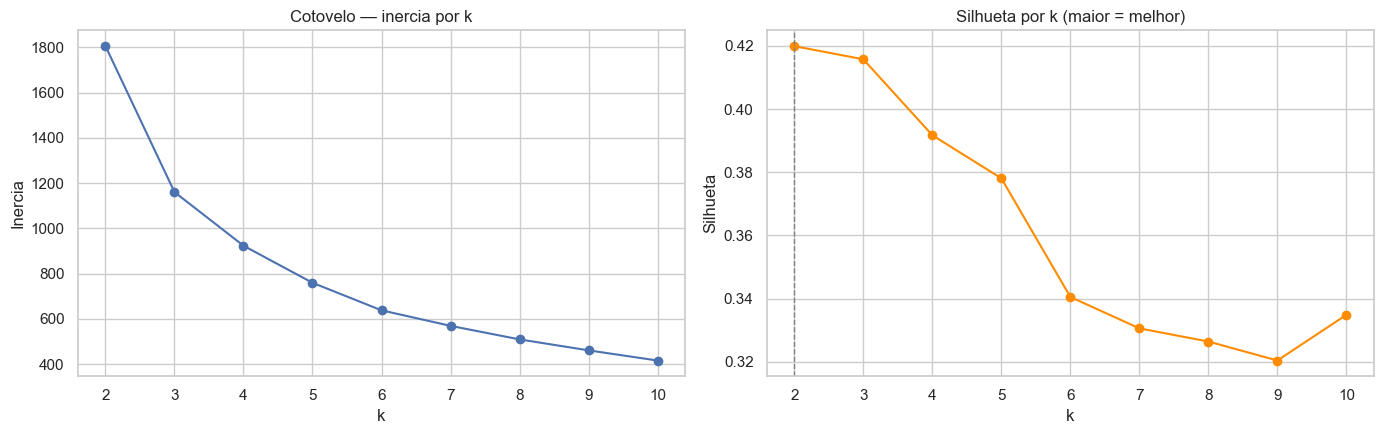

In [3]:
def avaliar_k(X, k_max=K_MAX, seed=SEED):
    """Roda KMeans para cada k e devolve inercia e silhueta."""
    linhas = []
    for k in range(2, k_max + 1):
        # n_init=10 explicito: sem isso, versoes recentes do sklearn rodam 1 inicializacao
        # e a curva fica serrilhada por sorte de inicializacao, nao por qualidade do k.
        km = KMeans(n_clusters=k, random_state=seed, n_init=10, max_iter=1000)
        rotulos = km.fit_predict(X)
        linhas.append({
            'k': k,
            'inercia': km.inertia_,
            'silhueta': silhouette_score(X, rotulos),
            'menor_cluster_pct': pd.Series(rotulos).value_counts(normalize=True).min() * 100,
        })
    return pd.DataFrame(linhas).set_index('k')


diag = avaliar_k(X)
print(diag.round(3).to_string())

melhor_silhueta = diag['silhueta'].idxmax()
print(f'\nMelhor silhueta: k={melhor_silhueta} ({diag.loc[melhor_silhueta, "silhueta"]:.3f})')

fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
axes[0].plot(diag.index, diag['inercia'], marker='o')
axes[0].set_title('Cotovelo — inercia por k')
axes[0].set_xlabel('k'); axes[0].set_ylabel('Inercia'); axes[0].set_xticks(diag.index)

axes[1].plot(diag.index, diag['silhueta'], marker='o', color='darkorange')
axes[1].axvline(melhor_silhueta, ls='--', c='gray', lw=1)
axes[1].set_title('Silhueta por k (maior = melhor)')
axes[1].set_xlabel('k'); axes[1].set_ylabel('Silhueta'); axes[1].set_xticks(diag.index)

plt.tight_layout(); plt.show()

**Explicação do bloco**

- `KMeans(n_clusters=k, random_state=seed, n_init=10, max_iter=1000)` — `n_init=10` roda o
  algoritmo dez vezes com centroides iniciais diferentes e guarda o melhor resultado. Sem
  esse parâmetro explícito, versões do scikit-learn a partir da 1.4 usam `n_init='auto'`,
  que com `init='k-means++'` significa **uma única** inicialização. Comparar valores de
  `k` nessas condições é comparar sorteios, não qualidade de agrupamento.
- `km.fit_predict(X)` — ajusta e devolve o rótulo de cada ponto numa chamada só.
- `km.inertia_` — atributo preenchido após o ajuste, com a soma das distâncias
  quadráticas intra-cluster.
- `silhouette_score(X, rotulos)` — calcula a silhueta média de todos os pontos. É a parte
  cara do laço: o cálculo é O(n²) por comparar cada ponto com todos os outros. Com
  dezenas de milhares de clientes vale amostrar (`sample_size=...`).
- `menor_cluster_pct` — **a coluna mais útil da tabela e a que quase nunca aparece nos
  tutoriais**. Mostra o tamanho do menor cluster em percentual. Um `k` com silhueta
  excelente mas cujo menor grupo tem 0,5% dos clientes produziu um cluster de outliers
  disfarçado, não um segmento: não dá para construir uma ação de marketing em cima dele.
  Este número é o que transforma a escolha de `k` numa decisão de negócio em vez de uma
  otimização cega.
- `axvline(melhor_silhueta, ...)` — marca visualmente o pico no gráfico da direita, para
  que a leitura do gráfico e o número da tabela não fiquem desconectados.

## 5. Ajuste final

A escolha de `k` é feita **programaticamente**, com uma regra de três partes que
operacionaliza o que a seção anterior descreveu em texto:

1. **Filtro de acionabilidade.** Só entram valores de `k` cujo menor cluster tenha pelo
   menos 5% dos clientes. Um cluster minúsculo é um bolsão de outliers, não um segmento.
2. **Referência de qualidade.** Entre os que passaram, toma-se a melhor silhueta.
3. **Preferência por granularidade.** Escolhe-se o **maior** `k` cuja silhueta esteja
   dentro de uma tolerância de 10% da melhor.

A regra 3 existe por um motivo concreto: em dados de RFM a silhueta costuma premiar
`k=2`, porque a divisão geometricamente mais limpa é simplesmente "comprou uma vez" vs
"comprou várias". Sem a regra 3, o notebook prevê esse problema na seção 4 e cai nele
mesmo assim — escolhendo dois clusters que ninguém consegue acionar de forma diferente.

A tolerância é a troca sendo feita de forma explícita: aceita-se até 10% de perda de
separação geométrica em troca de granularidade útil. Se nenhum `k` maior couber na
tolerância, a regra devolve o de melhor silhueta — inclusive `k=2`, quando é de fato a
única estrutura que os dados sustentam.

In [4]:
PCT_MINIMO_CLUSTER = 5.0     # tamanho minimo para um cluster ser acionavel
TOLERANCIA_SILHUETA = 0.10   # perda de silhueta aceita em troca de granularidade


def escolher_k(diag, pct_minimo=PCT_MINIMO_CLUSTER, tolerancia=TOLERANCIA_SILHUETA):
    """Maior k dentro da tolerancia de silhueta, entre os k acionaveis.

    Evita o k=2 degenerado que a silhueta costuma premiar em dados de RFM.
    """
    candidatos = diag[diag['menor_cluster_pct'] >= pct_minimo]
    if candidatos.empty:
        return int(diag['silhueta'].idxmax()), 'nenhum k acionavel; melhor silhueta'

    melhor_sil = candidatos['silhueta'].max()
    limite = melhor_sil * (1 - tolerancia)
    dentro = candidatos[candidatos['silhueta'] >= limite]
    k = int(dentro.index.max())
    k_sil_max = int(candidatos['silhueta'].idxmax())

    if k == k_sil_max:
        return k, 'maior silhueta e maior granularidade coincidem'
    return k, (f'maior k dentro de {tolerancia:.0%} da melhor silhueta '
               f'(k={k_sil_max} tinha a melhor, mas so {k_sil_max} clusters)')


K_ESCOLHIDO, criterio = escolher_k(diag)

print(f'k escolhido: {K_ESCOLHIDO}  ({criterio})')
print(f'  silhueta={diag.loc[K_ESCOLHIDO, "silhueta"]:.3f}  '
      f'menor cluster={diag.loc[K_ESCOLHIDO, "menor_cluster_pct"]:.1f}%')
print(f'\nComparacao entre os candidatos acionaveis (menor cluster >= {PCT_MINIMO_CLUSTER}%):')
print(diag[diag['menor_cluster_pct'] >= PCT_MINIMO_CLUSTER][['silhueta', 'menor_cluster_pct']]
      .round(3).to_string())

kmeans_final = KMeans(n_clusters=K_ESCOLHIDO, random_state=SEED, n_init=10, max_iter=1000)
rfm_base['Cluster'] = kmeans_final.fit_predict(X)

print(f'\nDistribuicao dos clusters:')
print(rfm_base['Cluster'].value_counts().sort_index().to_string())

k escolhido: 5  (maior k dentro de 10% da melhor silhueta (k=2 tinha a melhor, mas so 2 clusters))
  silhueta=0.378  menor cluster=11.2%

Comparacao entre os candidatos acionaveis (menor cluster >= 5.0%):
   silhueta  menor_cluster_pct
k                             
2      0.42              29.58
3      0.42              27.60
4      0.39              13.61
5      0.38              11.25
6      0.34              10.40
7      0.33               8.51
8      0.33               8.60

Distribuicao dos clusters:
Cluster
0    150
1    304
2    320
3    165
4    119


**Explicação do bloco**

- `diag[diag['menor_cluster_pct'] >= pct_minimo]` — filtra primeiro por acionabilidade.
  A ordem importa: qualidade estatística fica subordinada a uma restrição de negócio, não
  o contrário.
- `limite = melhor_sil * (1 - tolerancia)` seguido de `dentro.index.max()` — **a parte
  que evita o `k=2` degenerado**. Em vez de pegar o pico da silhueta, define-se uma faixa
  de "qualidade aceitável" (até 10% abaixo do pico) e, dentro dela, escolhe-se o `k`
  **maior**. É a tradução em código de "prefiro mais granularidade desde que a separação
  não piore muito".
- A função devolve `(k, criterio)` e o critério é impresso. Sem isso, um leitor que
  visse `k=3` não saberia se foi o pico da silhueta ou o resultado da regra de
  tolerância — e essas duas situações pedem leituras diferentes do resultado.
- O `if candidatos.empty` cobre o caso em que nenhum `k` atende ao mínimo de tamanho. Em
  vez de quebrar ou escolher em silêncio, cai num critério alternativo e o anuncia.
- A tabela de candidatos impressa no final deixa a decisão auditável: dá para ver qual
  era o pico, qual foi escolhido e quanto de silhueta custou a escolha.
- `rfm_base['Cluster'] = kmeans_final.fit_predict(X)` — os rótulos entram em `rfm_base`,
  que está em escala **original**. `X` é a versão transformada, usada só para treinar. É
  a separação que permite, na próxima seção, descrever os clusters em reais e em dias, e
  não em unidades de desvio-padrão do logaritmo — que não significam nada para ninguém.
  O alinhamento é garantido porque `X` foi construído com `index=rfm_base.index`.
- `max_iter=1000` — folga sobre o padrão (300). K-Means normalmente converge muito antes;
  o valor alto só garante que a convergência não seja interrompida por limite de iteração
  em algum `k` mais difícil.

## 6. Perfil e nomeação dos clusters

O rótulo de um cluster precisa sair do **perfil calculado**, nunca de uma expectativa
prévia. Nomear antes de olhar é como o clustering vira profecia autorrealizável: o
analista decide que existe um grupo "Champions", encontra um cluster qualquer e cola o
nome nele.

A função abaixo compara o centroide de cada cluster com a **mediana da base** em cada
dimensão e monta o nome a partir dessa comparação. O rótulo é, assim, uma descrição
verificável — e muda sozinho se os dados mudarem.

**O rótulo é relativo, e três decisões de desenho protegem contra ler demais nele:**

1. **Terços, não mediana.** Um corte binário coloca no mesmo rótulo clientes que estão
   logo abaixo e muito abaixo da mediana. Numa versão anterior desta função, dois
   clusters com valor mediano de 238 e de 34 recebiam o mesmo rótulo "abaixo da mediana",
   escondendo uma diferença de sete vezes. O terço do meio absorve exatamente os casos
   próximos da mediana, que são os que produzem rótulo enganoso.
2. **O rótulo descreve posição na base, não no mundo.** `R recente` significa "entre os
   33% mais recentes *desta* base". Numa base majoritariamente dormente, isso ainda pode
   ser vários meses.
3. **Os cortes são impressos junto da tabela.** O rótulo dá a direção, os valores dão a
   magnitude. Ler só o rótulo leva a conclusões que os números não sustentam.

Para `Recency` a escala é invertida, e a inversão fica codificada na **ordem** da tupla
em `NIVEIS` — o primeiro rótulo corresponde sempre ao menor valor bruto, que no caso da
recência é o cliente mais recente. Concentrar a inversão num único lugar evita que ela
seja aplicada duas vezes ou esquecida.

In [5]:
NIVEIS = {
    'Recency': ('recente', 'intermediaria', 'inativa'),     # invertida: menor = melhor
    'Frequency': ('baixa', 'media', 'alta'),
    'Monetary': ('baixo', 'medio', 'alto'),
}


def nomear_clusters(perfil, rfm_ref):
    """Rotula cada cluster posicionando seu centroide nos TERCOS da base.

    O rotulo e RELATIVO a esta base, nunca absoluto: 'R recente' significa "entre os
    33% mais recentes DESTA base", nao "comprou ha poucos dias".

    Tres niveis, e nao dois: um corte binario na mediana junta num mesmo rotulo
    clusters materialmente diferentes (ex.: valor mediano de 34 e de 238 cairiam
    ambos em "abaixo da mediana"). O terco do meio absorve os casos proximos da
    mediana, que sao justamente os que geram rotulo enganoso.
    """
    cortes = {col: rfm_ref[col].quantile([1 / 3, 2 / 3]).values for col in METRICAS}

    def nivel(col, valor):
        # A inversao da Recency ja esta codificada na ORDEM da tupla em NIVEIS:
        # o primeiro rotulo sempre corresponde ao MENOR valor bruto, e para
        # recencia o menor valor e justamente o cliente mais recente.
        c1, c2 = cortes[col]
        rotulos = NIVEIS[col]
        return rotulos[0] if valor <= c1 else (rotulos[1] if valor <= c2 else rotulos[2])

    return {c: (f"R {nivel('Recency', l['Recency'])} / "
                f"F {nivel('Frequency', l['Frequency'])} / "
                f"M {nivel('Monetary', l['Monetary'])}")
            for c, l in perfil.iterrows()}


perfil_clusters = rfm_base.groupby('Cluster').agg(
    n_clientes=('Recency', 'size'),
    Recency=('Recency', 'median'),
    Frequency=('Frequency', 'median'),
    Monetary=('Monetary', 'median'),
    receita_total=('Monetary', 'sum'),
)
perfil_clusters['pct_clientes'] = perfil_clusters['n_clientes'] / len(rfm_base) * 100
perfil_clusters['pct_receita'] = perfil_clusters['receita_total'] / rfm_base['Monetary'].sum() * 100

nomes = nomear_clusters(perfil_clusters, rfm_base)
perfil_clusters['perfil'] = pd.Series(nomes)
rfm_base['Cluster_Nome'] = rfm_base['Cluster'].map(nomes)

print('CORTES DA BASE (tercos) — referencia para os rotulos')
print(rfm_base[METRICAS].quantile([1/3, 2/3]).round(1).to_string())

print('\nPERFIL DOS CLUSTERS (medianas em escala original)')
print(perfil_clusters[['n_clientes', 'pct_clientes', 'Recency', 'Frequency',
                       'Monetary', 'pct_receita', 'perfil']].round(1).to_string())

CORTES DA BASE (tercos) — referencia para os rotulos
      Recency  Frequency  Monetary
0.33   266.00       1.00    179.50
0.67   513.70       2.00    504.00

PERFIL DOS CLUSTERS (medianas em escala original)
         n_clientes  pct_clientes  Recency  Frequency  Monetary  pct_receita                               perfil
Cluster                                                                                                          
0               150         14.20   198.50       5.50  1,326.80        36.10          R recente / F alta / M alto
1               304         28.70   184.00       1.00    235.80        17.10        R recente / F baixa / M medio
2               320         30.20   603.50       1.00    238.50        17.70        R inativa / F baixa / M medio
3               165         15.60   487.00       3.00    803.10        28.20    R intermediaria / F alta / M alto
4               119         11.20   475.00       1.00     34.60         0.90  R intermediaria / F baixa / M

**Explicação do bloco**

- `rfm_ref[METRICAS].median()` — a mediana, não a média, é a referência. Com distribuições
  assimétricas a média fica acima da maioria dos clientes, e comparar um centroide contra
  ela classificaria como "baixo valor" clientes que estão acima do cliente típico.
- `cortes = {col: rfm_ref[col].quantile([1/3, 2/3]).values ...}` — os dois pontos de
  corte por variável, calculados sobre a base inteira (não sobre cada cluster). São eles
  que tornam o rótulo comparável entre clusters.
- A inversão da Recência **não** aparece como um `if` dentro de `nivel`. Ela está na
  ordem da tupla em `NIVEIS`: como `('recente', 'intermediaria', 'inativa')` já começa
  pelo menor valor bruto, a mesma comparação `valor <= c1` serve para as três variáveis.
  Uma versão anterior tinha um ramo `if col == 'Recency'` que fazia exatamente a mesma
  coisa do ramo geral — código morto que parecia estar tratando a inversão e não estava.
- `r[0] if valor <= c1 else (r[1] if valor <= c2 else r[2])` — a cadeia condicional
  mapeia o valor ao terço correspondente. Três níveis em vez de dois é a correção de um
  problema real: com corte binário, clusters com valor mediano de 238 e de 34 recebiam
  ambos o rótulo "abaixo da mediana", apagando uma diferença de sete vezes.
- O perfil usa **mediana** de cada métrica por cluster (`'median'`), não média, pelo mesmo
  motivo — e também porque o centroide do K-Means está em espaço log-padronizado; a
  mediana em escala original é a forma honesta de descrever o grupo para quem vai ler.
- `pd.Series(nomes)` convertido em coluna e `rfm_base['Cluster'].map(nomes)` — o mesmo
  dicionário alimenta a tabela de perfil e a coluna por cliente, garantindo que os dois
  nunca divirjam.
- Um efeito colateral útil: dois clusters podem receber o **mesmo** nome. Quando isso
  acontece, é sinal de que o `k` escolhido está dividindo em duas partes um grupo que,
  nas três dimensões, se comporta igual — argumento concreto para reduzir `k`.

## 7. Clusters vs segmentação por regras

Esta é a seção que justifica ter feito as duas coisas. Aplicamos aqui a mesma regra de
padrão R/F/M usada na segmentação por quantis e cruzamos com os clusters.

Três leituras possíveis do cruzamento:

- **Concordância alta** — o clustering confirma que as faixas escolhidas correspondem a
  agrupamentos reais. As regras ganham respaldo empírico.
- **Um cluster se espalha por vários segmentos** — o algoritmo encontrou um padrão que a
  regra não representa. Vale investigar o que esses clientes têm em comum.
- **Um segmento se espalha por vários clusters** — a regra está juntando clientes que se
  comportam de forma diferente; ela pode estar grossa demais.

In [6]:
LIMIAR_ALTO, LIMIAR_BAIXO, N_SCORES = 4, 2, 5


def pontuar(serie, n=N_SCORES, maior_melhor=True, cortes_fixos=None):
    """Quantis -> cortes fixos -> quantis sobre rank (mesma logica da analise por regras)."""
    labels = list(range(1, n + 1)) if maior_melhor else list(range(n, 0, -1))
    bordas = serie.quantile(np.linspace(0, 1, n + 1)).values
    if len(np.unique(bordas)) == n + 1:
        return pd.qcut(serie, q=n, labels=labels).astype(int)
    if cortes_fixos is not None and len(cortes_fixos) == n + 1:
        return pd.cut(serie, bins=cortes_fixos, labels=labels).astype(int)
    return pd.qcut(serie.rank(method='first'), q=n, labels=labels).astype(int)


def segmentar(linha):
    r, f, m = linha['R'], linha['F'], linha['M']
    r_alto, r_baixo = r >= LIMIAR_ALTO, r <= LIMIAR_BAIXO
    f_alto, m_alto = f >= LIMIAR_ALTO, m >= LIMIAR_ALTO
    f_baixo, m_baixo = f <= LIMIAR_BAIXO, m <= LIMIAR_BAIXO
    if r_alto and f_alto and m_alto:
        return 'VIP/Loyal'
    if r_baixo and f_alto and m_alto:
        return "Can't Lose"
    if r_baixo and (f_alto or m_alto):
        return 'At Risk'
    if r_baixo and f_baixo and m_baixo:
        return 'Lost'
    if r_alto:
        return 'Potential Loyal'
    return 'Regular'


rfm_base['R'] = pontuar(rfm_base['Recency'], maior_melhor=False)
rfm_base['F'] = pontuar(rfm_base['Frequency'], cortes_fixos=[0, 1, 2, 3, 5, np.inf])
rfm_base['M'] = pontuar(rfm_base['Monetary'])
rfm_base['Segmento'] = rfm_base.apply(segmentar, axis=1)

cruzamento = pd.crosstab(rfm_base['Cluster_Nome'], rfm_base['Segmento'])
print('CLUSTERS (linhas) x SEGMENTOS POR REGRA (colunas)')
print(cruzamento.to_string())

# Concordancia: fracao de clientes no par (cluster, segmento) dominante de cada cluster
dominante = cruzamento.max(axis=1).sum() / cruzamento.values.sum()
print(f'\nConcordancia: {dominante:.1%} dos clientes caem no segmento dominante do seu cluster.')
print('Quanto mais alto, mais o algoritmo reproduz as regras definidas manualmente.')

CLUSTERS (linhas) x SEGMENTOS POR REGRA (colunas)
Segmento                             At Risk  Can't Lose  Lost  Potential Loyal  Regular  VIP/Loyal
Cluster_Nome                                                                                       
R inativa / F baixa / M medio             51           0   137                0      132          0
R intermediaria / F alta / M alto         45          40     0                3       77          0
R intermediaria / F baixa / M baixo        0           0    62               29       28          0
R recente / F alta / M alto                0           0     0               23       22        105
R recente / F baixa / M medio              0           0     0              265       39          0

Concordancia: 61.1% dos clientes caem no segmento dominante do seu cluster.
Quanto mais alto, mais o algoritmo reproduz as regras definidas manualmente.


**Explicação do bloco**

- As funções `pontuar` e `segmentar` são as mesmas da análise por regras, reproduzidas de
  forma condensada. Precisam ser idênticas para que a comparação seja legítima — se os
  cortes fossem diferentes, a discordância mediria a diferença entre as regras, não entre
  regra e algoritmo.
- **Atenção metodológica:** os scores aqui são calculados sobre `rfm_base`, que já teve os
  outliers removidos. Isso significa que os segmentos deste notebook não são idênticos aos
  da análise original, que usava a base completa. A comparação continua válida porque os
  dois lados do cruzamento partem do mesmo conjunto de clientes, mas é a razão de não se
  poder colar esta tabela ao lado da tabela do outro notebook e tratá-las como a mesma
  coisa.
- `pd.crosstab(...)` — tabela de contingência: cada célula conta clientes naquela
  combinação de cluster e segmento.
- `cruzamento.max(axis=1).sum() / cruzamento.values.sum()` — a métrica de concordância.
  `max(axis=1)` pega, para cada cluster, a maior contagem entre os segmentos (o segmento
  dominante daquele cluster); somando esses máximos e dividindo pelo total, obtém-se a
  fração de clientes que caem no par dominante. É uma medida simples de sobreposição
  entre as duas segmentações: perto de 1 significa que o algoritmo redescobriu as regras;
  valores baixos significam que ele está enxergando outra coisa.

## 8. Visualizações

Dois gráficos, cada um respondendo algo que a tabela não responde.

**Gráfico 1 — dispersão Recência × Monetário, colorida por cluster.** Mostra se os grupos
ocupam regiões distintas do espaço ou se estão embolados. É a verificação visual de que o
`k` escolhido produziu separação real. O eixo de valor usa escala logarítmica, coerente
com a transformação aplicada antes do ajuste.

**Gráfico 2 — perfil normalizado por cluster.** Permite comparar clusters de magnitudes
diferentes na mesma escala, respondendo "em que cada cluster é alto ou baixo" em vez de
"qual tem o maior número absoluto".

In [7]:
plot_df = rfm_base.reset_index()
plot_df['Cluster_Nome'] = plot_df['Cluster'].astype(str) + ': ' + plot_df['Cluster_Nome']

fig = px.scatter(
    plot_df, x='Recency', y='Monetary', color='Cluster_Nome',
    size='Frequency', size_max=18, opacity=0.65, log_y=True,
    title=f'Clusters no espaco Recencia x Monetario (k={K_ESCOLHIDO})',
    labels={'Recency': 'Recencia (dias — menor = mais recente)',
            'Monetary': 'Monetario (escala log)', 'Cluster_Nome': 'Cluster'},
    color_discrete_sequence=px.colors.qualitative.Set2,
    hover_data={'Frequency': True, 'Segmento': True},
)
fig.update_layout(legend=dict(orientation='h', yanchor='bottom', y=-0.35))
fig.show()

**Explicação do bloco**

- `plot_df['Cluster_Nome'] = ... astype(str) + ': ' + ...` — prefixa o número do cluster
  ao nome descritivo. Sem isso, dois clusters que receberam o mesmo rótulo (situação
  possível, como notado na seção 6) apareceriam fundidos numa única cor na legenda.
- `log_y=True` — o eixo monetário em escala logarítmica. É consistente com o `log1p`
  aplicado antes do ajuste: o algoritmo enxergou os dados nessa escala, então visualizá-los
  em escala linear mostraria uma separação diferente da que o modelo usou. Em escala
  linear, os clientes de alto valor empurrariam todo o resto para uma faixa fina na base
  do gráfico.
- `size='Frequency'` — a terceira dimensão entra como tamanho do ponto, o que evita um
  gráfico 3D (bonito e difícil de ler) sem perder a variável.
- `opacity=0.65` — com mais de mil pontos, a sobreposição esconde densidade. A
  transparência faz regiões densas aparecerem mais escuras.
- `hover_data={'Frequency': True, 'Segmento': True}` — permite inspecionar um ponto
  específico e ver como as duas segmentações o classificaram, o que é a forma prática de
  investigar as discordâncias encontradas na seção 7.
- `legend=dict(orientation='h', ...)` — legenda horizontal abaixo do gráfico, porque os
  rótulos descritivos ("recente / frequente / alto valor") são longos e, na vertical,
  comprimiriam a área do gráfico.

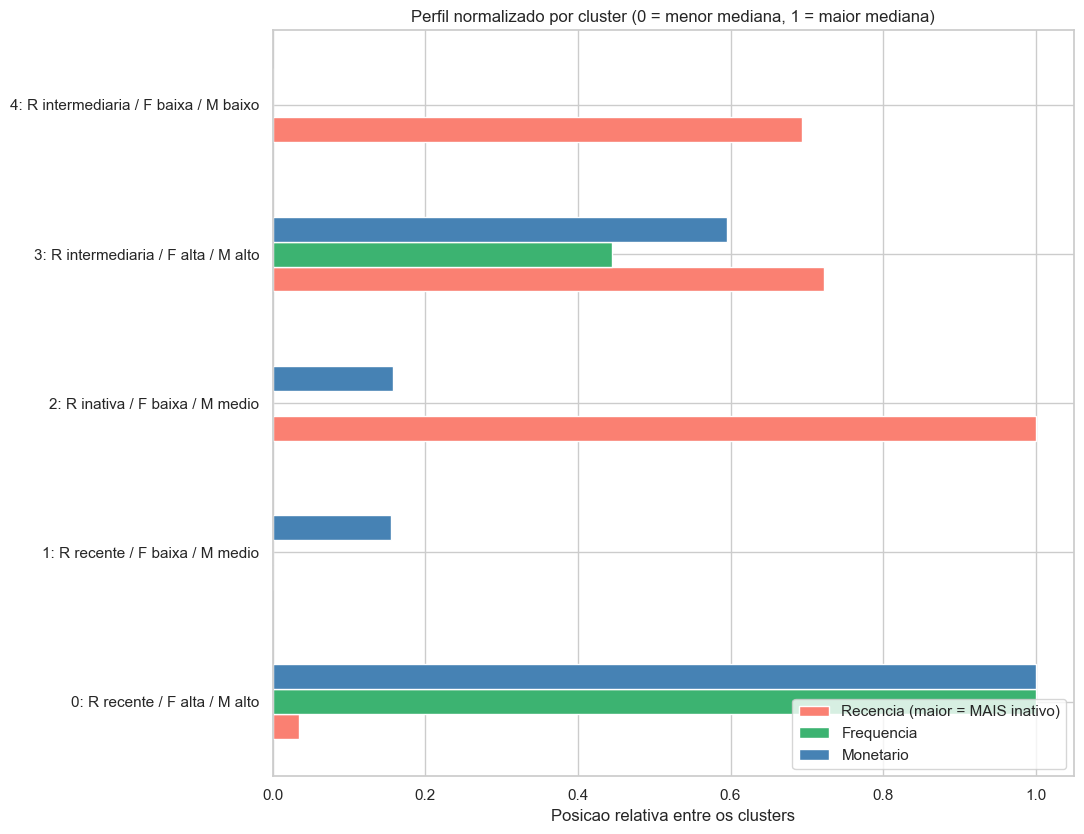

Valores medianos em escala original:
         Recency  Frequency  Monetary                               perfil
Cluster                                                                   
0         198.50       5.50  1,326.80          R recente / F alta / M alto
1         184.00       1.00    235.80        R recente / F baixa / M medio
2         603.50       1.00    238.50        R inativa / F baixa / M medio
3         487.00       3.00    803.10    R intermediaria / F alta / M alto
4         475.00       1.00     34.60  R intermediaria / F baixa / M baixo


In [8]:
perfil_norm = perfil_clusters[METRICAS].copy()
# Min-max por coluna: cada metrica vai para 0-1, tornando as tres comparaveis no grafico.
perfil_norm = (perfil_norm - perfil_norm.min()) / (perfil_norm.max() - perfil_norm.min())
perfil_norm.index = [f'{i}: {nomes[i]}' for i in perfil_norm.index]

ax = perfil_norm.plot(kind='barh', figsize=(11, 1.3 * len(perfil_norm) + 2),
                      color=['salmon', 'mediumseagreen', 'steelblue'])
ax.set_title('Perfil normalizado por cluster (0 = menor mediana, 1 = maior mediana)')
ax.set_xlabel('Posicao relativa entre os clusters')
ax.legend(['Recencia (maior = MAIS inativo)', 'Frequencia', 'Monetario'],
          loc='lower right')
plt.tight_layout(); plt.show()

print('Valores medianos em escala original:')
print(perfil_clusters[['Recency', 'Frequency', 'Monetary', 'perfil']].round(1).to_string())

**Explicação do bloco**

- `(x - min) / (max - min)` — normalização min-max aplicada **coluna a coluna**, sobre as
  medianas dos clusters. Cada métrica passa a variar de 0 a 1, onde 0 é o cluster com a
  menor mediana naquela dimensão e 1 o de maior. Sem isso, `Monetary` (casa dos milhares)
  tornaria `Frequency` (casa das unidades) invisível no mesmo gráfico.
- **O que essa normalização custa:** ela é relativa *aos clusters*, não à base. Um valor 1
  significa "o maior entre os clusters", não "alto em termos absolutos". Por isso a tabela
  com os valores em escala original é impressa logo abaixo — o gráfico mostra a forma, a
  tabela mostra a magnitude, e as duas juntas evitam a leitura errada.
- `kind='barh'` — barras horizontais, porque os rótulos dos clusters são frases. Na
  vertical, ficariam rotacionados e ilegíveis.
- `figsize=(11, 1.3 * len(perfil_norm) + 2)` — a altura acompanha o número de clusters, de
  forma que o gráfico não fique espremido se o `k` escolhido mudar.
- A legenda reforça mais uma vez a inversão da Recência (`maior = MAIS inativo`). Neste
  gráfico específico o valor **não** está invertido — ele é a recência em dias, então
  barra grande significa cliente parado. É o ponto do notebook onde a confusão de sinal é
  mais provável, e por isso a anotação está no próprio eixo e não numa nota de rodapé.

## 9. Limitações

1. **K-Means impõe a forma dos grupos.** O algoritmo procura agrupamentos aproximadamente
   esféricos e de tamanhos parecidos. Se a estrutura real dos dados for alongada ou de
   densidades muito diferentes, ele vai particionar mesmo assim — K-Means **sempre**
   devolve `k` clusters, existindo estrutura ou não. DBSCAN ou modelos de mistura
   gaussiana seriam alternativas quando há suspeita de formatos irregulares.

2. **Os outliers removidos são clientes reais.** A base de clustering exclui os maiores
   compradores. Eles continuam em `rfm_outliers` e precisam de tratamento à parte — o mais
   comum é atribuí-los ao centroide mais próximo depois do ajuste, ou tratá-los como um
   segmento próprio de contas estratégicas.

3. **O resultado não é estável entre execuções com dados diferentes.** Os clusters são
   definidos pela geometria da base atual. Rodar no mês seguinte pode produzir uma
   partição diferente, e os rótulos numéricos (`Cluster 0`, `Cluster 1`) não têm
   continuidade garantida entre execuções. Para acompanhamento no tempo, é preciso
   congelar o modelo (`kmeans_final`) e aplicar `.predict()` aos novos dados, em vez de
   reajustar.

4. **Três features é pouco.** O clustering só enxerga R, F e M. A base transacional
   permite derivar tempo de casa, intervalo entre compras, variabilidade de ticket e
   tendência recente — variáveis que costumam separar melhor do que as três originais.

5. **A silhueta mede geometria, não utilidade.** Um `k` com silhueta alta pode produzir
   grupos que a operação não consegue tratar de forma diferente. A restrição de tamanho
   mínimo aplicada na seção 5 é uma proteção parcial contra isso, mas não substitui
   validação com a área de negócio.

6. **Base sintética.** Como registrado na seção 2, os dados reais não foram fornecidos.
   Os números desta execução descrevem dados gerados.

## 10. Código completo

Pipeline consolidado e autossuficiente. Roda como script ou notebook, sem dependência de
nenhuma célula anterior.

Clientes: 1,167 -> 1,058 (109 outliers removidos, 36.0% da receita)
AVISO: >25% da receita fora — trate `rfm_outliers` a parte.
log1p aplicado em: ['Frequency', 'Monetary']
    inercia  silhueta  menor_cluster_pct
k                                       
2  1,805.25      0.42              29.58
3  1,160.49      0.42              27.60
4    923.50      0.39              13.61
5    759.67      0.38              11.25
6    638.03      0.34              10.40
7    569.40      0.33               8.51
8    509.62      0.33               8.60
9    461.15      0.32               3.50
10   416.19      0.34               3.31

k escolhido: 5 (silhueta=0.378, menor cluster=11.2%)

PERFIL DOS CLUSTERS
         n_clientes  pct_clientes  Recency  Frequency  Monetary  pct_receita                               perfil
Cluster                                                                                                          
0               150         14.20   198.50       5.50  1,326.80        36

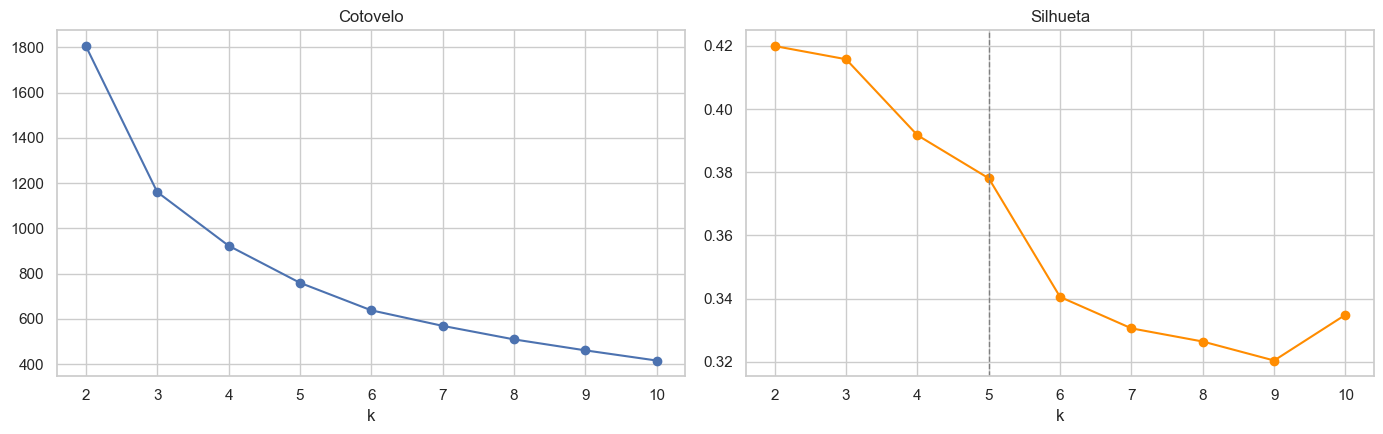

In [9]:
"""CLUSTERING DE CLIENTES COM K-MEANS SOBRE RFM — pipeline consolidado."""

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

pd.set_option('display.float_format', lambda v: f'{v:,.2f}')
sns.set_theme(style='whitegrid')

SEED, K_MAX, PCT_MINIMO_CLUSTER, TOLERANCIA_SILHUETA = 42, 10, 5.0, 0.10
LIMIAR_SKEW, PCT_RECEITA_ALERTA = 0.75, 25
METRICAS = ['Recency', 'Frequency', 'Monetary']


def gerar_base_sintetica(n_clientes=1200, seed=SEED):
    """ASSUMPTION: base real nao disponivel — substitua por pd.read_csv(...)."""
    rng = np.random.default_rng(seed)
    fim_janela = pd.Timestamp('2011-12-09')
    linhas, invoice = [], 500000
    for cliente in range(1, n_clientes + 1):
        dias_desde_ultima = int(rng.integers(0, 730))
        n_pedidos = 1 if rng.random() < 0.55 else int(rng.integers(2, 15))
        intervalo = int(rng.integers(10, 120))
        for p in range(n_pedidos):
            offset = dias_desde_ultima + p * intervalo
            if offset > 729:
                break
            invoice += 1
            data = fim_janela - pd.Timedelta(days=offset) + pd.Timedelta(hours=int(rng.integers(8, 19)))
            devolucao = rng.random() < 0.04
            for _ in range(int(rng.integers(1, 6))):
                qtd = -int(rng.integers(1, 5)) if devolucao else int(rng.integers(1, 15))
                preco = round(float(rng.lognormal(mean=2.0, sigma=0.9)), 2)
                linhas.append((cliente, str(invoice), data, qtd, preco))
    df = pd.DataFrame(linhas, columns=['Customer ID', 'Invoice', 'InvoiceDate', 'Quantity', 'Price'])
    df.loc[df.sample(frac=0.018, random_state=1).index, 'Customer ID'] = np.nan
    df.loc[df.sample(frac=0.006, random_state=2).index, 'Price'] = 0.0
    df = pd.concat([df, df.sample(frac=0.01, random_state=3)], ignore_index=True)
    return df.sample(frac=1, random_state=4).reset_index(drop=True)


def preparar_dados(df):
    df = df.dropna(subset=['Customer ID', 'InvoiceDate', 'Quantity', 'Price']).copy()
    df = df.drop_duplicates()
    df['Customer ID'] = df['Customer ID'].astype('int64')
    df['LineTotal'] = df['Quantity'] * df['Price']
    df['eh_devolucao'] = df['Quantity'] < 0
    return df[~((df['Price'] <= 0) & (~df['eh_devolucao']))]


def calcular_rfm(df):
    """Monetary liquido (com devolucoes); Recency/Frequency so sobre compras efetivas."""
    reference_date = df['InvoiceDate'].max() + pd.Timedelta(days=1)
    compras = df[~df['eh_devolucao']]
    monetario = df.groupby('Customer ID').agg(Monetary=('LineTotal', 'sum'))
    atividade = compras.groupby('Customer ID').agg(
        Frequency=('Invoice', 'nunique'),
        UltimaCompra=('InvoiceDate', 'max'),
    )
    rfm = monetario.join(atividade, how='inner')
    rfm['Recency'] = (reference_date - rfm['UltimaCompra']).dt.days
    return rfm[rfm['Monetary'] > 0].drop(columns='UltimaCompra')


def remover_outliers_iqr(rfm, colunas=('Monetary', 'Frequency'), fator=1.5):
    """Necessario para K-Means (distancia euclidiana), ao contrario do score por quantil."""
    fora = pd.Series(False, index=rfm.index)
    for col in colunas:
        q1, q3 = rfm[col].quantile([0.25, 0.75])
        iqr = q3 - q1
        fora |= (rfm[col] < q1 - fator * iqr) | (rfm[col] > q3 + fator * iqr)
    return rfm[~fora].copy(), rfm[fora].copy()


def preparar_features(rfm_base, limiar_skew=LIMIAR_SKEW):
    """log1p SO onde ha cauda a direita relevante; depois padroniza.

    Aplicar log1p em variavel ja simetrica CRIA assimetria a esquerda.
    """
    X = rfm_base[METRICAS].copy()
    transformadas = [c for c in METRICAS if X[c].skew() > limiar_skew]
    X[transformadas] = np.log1p(X[transformadas])
    print(f'log1p aplicado em: {transformadas or "nenhuma coluna"}')
    Xs = StandardScaler().fit_transform(X)
    return pd.DataFrame(Xs, index=rfm_base.index, columns=METRICAS)


def avaliar_k(X, k_max=K_MAX, seed=SEED):
    linhas = []
    for k in range(2, k_max + 1):
        km = KMeans(n_clusters=k, random_state=seed, n_init=10, max_iter=1000)
        rotulos = km.fit_predict(X)
        linhas.append({'k': k, 'inercia': km.inertia_,
                       'silhueta': silhouette_score(X, rotulos),
                       'menor_cluster_pct': pd.Series(rotulos).value_counts(normalize=True).min() * 100})
    return pd.DataFrame(linhas).set_index('k')


def escolher_k(diag, pct_minimo=PCT_MINIMO_CLUSTER, tolerancia=TOLERANCIA_SILHUETA):
    """Maior k dentro da tolerancia de silhueta, entre os k acionaveis.

    Evita o k=2 degenerado que a silhueta costuma premiar em dados de RFM.
    """
    candidatos = diag[diag['menor_cluster_pct'] >= pct_minimo]
    if candidatos.empty:
        return int(diag['silhueta'].idxmax())
    limite = candidatos['silhueta'].max() * (1 - tolerancia)
    return int(candidatos[candidatos['silhueta'] >= limite].index.max())


NIVEIS = {
    'Recency': ('recente', 'intermediaria', 'inativa'),   # invertida: menor = melhor
    'Frequency': ('baixa', 'media', 'alta'),
    'Monetary': ('baixo', 'medio', 'alto'),
}


def nomear_clusters(perfil, rfm_ref):
    """Rotulo RELATIVO: posiciona o centroide nos tercos da base. Tres niveis,
    porque um corte binario junta clusters materialmente diferentes."""
    cortes = {c: rfm_ref[c].quantile([1 / 3, 2 / 3]).values for c in METRICAS}

    def nivel(col, valor):
        c1, c2 = cortes[col]
        r = NIVEIS[col]   # ordem da tupla ja codifica a inversao da recencia
        return r[0] if valor <= c1 else (r[1] if valor <= c2 else r[2])

    return {c: (f"R {nivel('Recency', l['Recency'])} / F {nivel('Frequency', l['Frequency'])} / "
                f"M {nivel('Monetary', l['Monetary'])}")
            for c, l in perfil.iterrows()}


def executar(mostrar_graficos=True):
    raw_df = gerar_base_sintetica()      # <-- trocar por pd.read_csv(...) na base real
    raw_df['InvoiceDate'] = pd.to_datetime(raw_df['InvoiceDate'])
    rfm = calcular_rfm(preparar_dados(raw_df))

    rfm_base, rfm_outliers = remover_outliers_iqr(rfm)
    pct_fora = rfm_outliers['Monetary'].sum() / rfm['Monetary'].sum() * 100
    print(f'Clientes: {len(rfm):,} -> {len(rfm_base):,} ({len(rfm_outliers)} outliers removidos, '
          f'{pct_fora:.1f}% da receita)')
    if pct_fora > PCT_RECEITA_ALERTA:
        print(f'AVISO: >{PCT_RECEITA_ALERTA}% da receita fora — trate `rfm_outliers` a parte.')

    X = preparar_features(rfm_base)
    diag = avaliar_k(X)
    print(diag.round(3).to_string())

    k = escolher_k(diag)
    print(f'\nk escolhido: {k} (silhueta={diag.loc[k, "silhueta"]:.3f}, '
          f'menor cluster={diag.loc[k, "menor_cluster_pct"]:.1f}%)')

    kmeans_final = KMeans(n_clusters=k, random_state=SEED, n_init=10, max_iter=1000)
    rfm_base['Cluster'] = kmeans_final.fit_predict(X)

    perfil = rfm_base.groupby('Cluster').agg(
        n_clientes=('Recency', 'size'),
        Recency=('Recency', 'median'), Frequency=('Frequency', 'median'),
        Monetary=('Monetary', 'median'), receita_total=('Monetary', 'sum'))
    perfil['pct_clientes'] = perfil['n_clientes'] / len(rfm_base) * 100
    perfil['pct_receita'] = perfil['receita_total'] / rfm_base['Monetary'].sum() * 100
    perfil['perfil'] = pd.Series(nomear_clusters(perfil, rfm_base))
    rfm_base['Cluster_Nome'] = rfm_base['Cluster'].map(nomear_clusters(perfil, rfm_base))

    print('\nPERFIL DOS CLUSTERS')
    print(perfil[['n_clientes', 'pct_clientes', 'Recency', 'Frequency',
                  'Monetary', 'pct_receita', 'perfil']].round(1).to_string())

    if mostrar_graficos:
        fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
        axes[0].plot(diag.index, diag['inercia'], marker='o')
        axes[0].set_title('Cotovelo'); axes[0].set_xlabel('k')
        axes[1].plot(diag.index, diag['silhueta'], marker='o', color='darkorange')
        axes[1].axvline(k, ls='--', c='gray', lw=1)
        axes[1].set_title('Silhueta'); axes[1].set_xlabel('k')
        plt.tight_layout(); plt.show()

    return rfm_base, perfil, kmeans_final, rfm_outliers


if __name__ == '__main__':
    rfm_final, perfil_final, modelo, outliers = executar()

**Explicação do bloco consolidado**

A sequência é a mesma das seções 2 a 6, com cada etapa isolada numa função:

1. `gerar_base_sintetica` / `preparar_dados` / `calcular_rfm` — o único ponto a trocar
   para usar dados reais é a primeira chamada dentro de `executar`.
2. `remover_outliers_iqr` — devolve as duas partes. A docstring registra o contraste com
   a análise por quantis, que é a decisão mais contraintuitiva do notebook.
3. `preparar_features` — encapsula a ordem correta (`log1p` → `StandardScaler`) numa
   função, de forma que ela não possa ser invertida por acidente em outro ponto do código.
4. `avaliar_k` — devolve as três colunas de diagnóstico, incluindo `menor_cluster_pct`.
5. `escolher_k` — a regra de decisão vira código: restrição de tamanho primeiro,
   silhueta depois.
6. `nomear_clusters` — o rótulo sai do perfil.
7. `executar` — orquestra e é o único ponto com `print`; `mostrar_graficos=False` permite
   reaproveitar o pipeline num processo sem interface.

O retorno inclui `kmeans_final` (o modelo ajustado) e `rfm_outliers`. Os dois são
necessários para o uso em produção descrito na limitação 3: o modelo para aplicar
`.predict()` a novos clientes sem reajustar — o que mantém os rótulos de cluster estáveis
no tempo — e a tabela de outliers para o tratamento à parte descrito na limitação 2.